# 02 — Naive Bayes Classifier for Taglish Sentiment Classification
**Project:** Sentiment Analysis of Taglish E-Commerce Reviews using Naive Bayes and XLM-RoBERTa

**Notebook owner:** [Your Name] (NB Person)

**Role:** Train and evaluate a Multinomial Naive Bayes classifier on FiReCS. Extract top features per class and produce `nb_predictions.csv` for the comparison notebook.

**Day 1 goal:** Full NB pipeline — hyperparameter sweep, final evaluation, top features, predictions saved.

**Day 2 goal:** Error analysis on pragmatic marker misclassifications.

## 0. Setup
Mount Google Drive, configure shared paths, and install dependencies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DRIVE_BASE     = "/content/drive/MyDrive/Machine Learning - Group 5/Finals Project/taglish-project"
DATA_PROCESSED = f"{DRIVE_BASE}/data/firecs_processed.csv"
OUTPUTS        = f"{DRIVE_BASE}/outputs"
FIGURES        = f"{DRIVE_BASE}/outputs/figures"

os.makedirs(FIGURES, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

print("Paths set:", DRIVE_BASE)

Paths set: /content/drive/MyDrive/Machine Learning - Group 5/Finals Project/taglish-project


In [ ]:
# NB only needs scikit-learn and standard data/plot libraries
!pip install pandas matplotlib seaborn scikit-learn -q

## 1. Load Processed Data
Load `firecs_processed.csv` produced by Notebook 01.
Separate train and test splits — test set is not touched until final evaluation.

In [ ]:
import pandas as pd

# Load the processed dataset produced by notebook 01
processed = pd.read_csv(DATA_PROCESSED)

# Separate train and test splits
train_df = processed[processed['split'] == 'train'].reset_index(drop=True)
test_df  = processed[processed['split'] == 'test'].reset_index(drop=True)

# Confirm
print("Train:", len(train_df), "| Test:", len(test_df))
print("Columns:", processed.columns.tolist())
print("\nSample:")
display(train_df.head(3))

Train: 7340 | Test: 3147
Columns: ['review', 'label', 'split']

Sample:


,review,label,split
0,im very disappointed kasi di gumana ang dalawa...,0,train
1,10 10 it has minor damage when it was delivere...,1,train
2,super ganda then tama ung size and color sa uu...,2,train


## 2. TF-IDF Pipeline and Hyperparameter Sweep
Build TF-IDF vectorizer fitted on train only (no leakage).
Sweep alpha ∈ {0.01, 0.1, 0.5, 1.0} × ngram_range ∈ {(1,1), (1,2)}.
Best config selected on a 10% validation hold-out from the training set.

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Fix seed for reproducibility
RANDOM_STATE = 42

# Carve out a 10% validation set from train (for hyperparameter selection)
# Test set is untouched until final evaluation
X_train_full = train_df['review']
y_train_full = train_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10, random_state=RANDOM_STATE, stratify=y_train_full
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(test_df)}")

# Hyperparameter grid
alphas      = [0.01, 0.1, 0.5, 1.0]
ngram_ranges = [(1,1), (1,2)]

results = []

for ngram in ngram_ranges:
    # Fit TF-IDF on train only, transform val — no leakage
    tfidf = TfidfVectorizer(ngram_range=ngram, min_df=2)
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_val_tfidf   = tfidf.transform(X_val)

    for alpha in alphas:
        nb = MultinomialNB(alpha=alpha)
        nb.fit(X_train_tfidf, y_train)
        preds = nb.predict(X_val_tfidf)

        acc = accuracy_score(y_val, preds)
        f1  = f1_score(y_val, preds, average='weighted')

        results.append({
            'ngram_range': ngram,
            'alpha': alpha,
            'val_accuracy': round(acc, 4),
            'val_f1': round(f1, 4)
        })
        print(f"ngram={ngram} | alpha={alpha} | acc={acc:.4f} | f1={f1:.4f}")

# Find best config by weighted F1
results_df = pd.DataFrame(results)
best = results_df.loc[results_df['val_f1'].idxmax()]
print(f"\nBest config:\n{best}")

Train: 6606 | Val: 734 | Test: 3147
ngram=(1, 1) | alpha=0.01 | acc=0.7411 | f1=0.7436
ngram=(1, 1) | alpha=0.1 | acc=0.7793 | f1=0.7813
ngram=(1, 1) | alpha=0.5 | acc=0.7984 | f1=0.8001
ngram=(1, 1) | alpha=1.0 | acc=0.7888 | f1=0.7907
ngram=(1, 2) | alpha=0.01 | acc=0.7561 | f1=0.7583
ngram=(1, 2) | alpha=0.1 | acc=0.7984 | f1=0.7994
ngram=(1, 2) | alpha=0.5 | acc=0.8052 | f1=0.8065
ngram=(1, 2) | alpha=1.0 | acc=0.8011 | f1=0.8027

Best config:
ngram_range     (1, 2)
alpha              0.5
val_accuracy    0.8052
val_f1          0.8065
Name: 6, dtype: object


## 3. Final Model Training and Evaluation
Retrain best config (ngram=(1,2), α=0.5) on the full training set.
Evaluate on the held-out test set: accuracy, weighted F1, per-class P/R/F1, confusion matrix.

Test Accuracy: 0.7909
Test Weighted F1: 0.7928

Per-class report:
              precision    recall  f1-score   support

    Negative       0.82      0.76      0.79      1027
     Neutral       0.69      0.76      0.72      1087
    Positive       0.89      0.85      0.87      1033

    accuracy                           0.79      3147
   macro avg       0.80      0.79      0.79      3147
weighted avg       0.80      0.79      0.79      3147



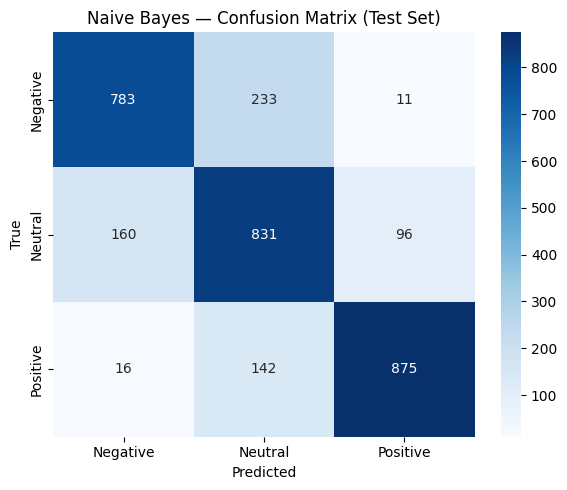

Saved: nb_confusion_matrix.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train final model on full train set using best config
tfidf_final = TfidfVectorizer(ngram_range=(1,2), min_df=2)
X_train_final = tfidf_final.fit_transform(X_train_full)  # full train, no val holdout
X_test_final  = tfidf_final.transform(test_df['review'])  # transform test

y_test = test_df['label']

nb_final = MultinomialNB(alpha=0.5)
nb_final.fit(X_train_final, y_train_full)

# Final predictions on test set
nb_preds = nb_final.predict(X_test_final)

# --- Metrics ---
acc = accuracy_score(y_test, nb_preds)
f1  = f1_score(y_test, nb_preds, average='weighted')

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Weighted F1: {f1:.4f}")
print(f"\nPer-class report:")
print(classification_report(y_test, nb_preds, target_names=['Negative','Neutral','Positive']))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, nb_preds)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'], ax=ax)
ax.set_title('Naive Bayes — Confusion Matrix (Test Set)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(f"{FIGURES}/nb_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: nb_confusion_matrix.png")

## 4. Top Features per Class
Extract top 20 discriminative tokens per class using log-likelihood ratio:
log P(token|class) − max log P(token|other classes).
This is the key interpretability artifact for RQ4a.


--- Negative ---
  sayang pera               2.8050
  so disappointed           2.5840
  nakaka disappoint         2.3977
  not satisfied             2.3681
  very disappointed         2.3116
  wag kayo                  2.2709
  scammer                   2.2422
  poor quality              2.1545
  panget                    2.1497
  waste of                  2.1090
  lang pera                 2.0964
  disappointed              2.0881
  not recommend             2.0600
  poor                      2.0293
  wag na                    2.0280
  not order                 2.0264
  binigay nyo               1.9900
  kwenta                    1.9791
  nakakadismaya             1.9781
  waste                     1.9745

--- Neutral ---
  kaso may                  2.0612
  kaso yung                 2.0215
  siya kaso                 1.9693
  kaso maliit               1.9575
  naman kaso                1.8671
  kaso ang                  1.8067
  size pero                 1.7137
  dumating pero     

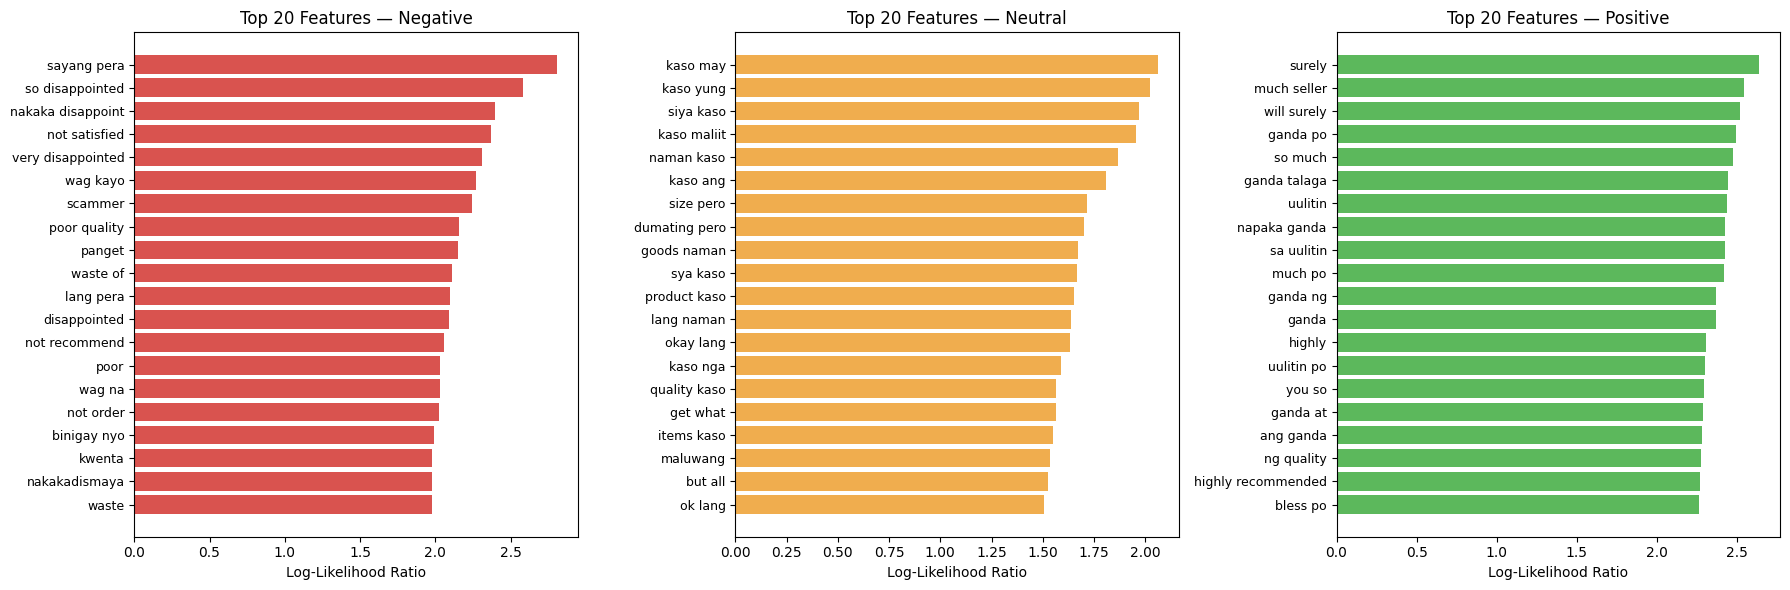


Saved: nb_top_features.png


In [ ]:
# Extract top 20 features per class by log-likelihood ratio
import numpy as np

# Log probability of each token given each class
log_probs = nb_final.feature_log_prob_  # shape: (3, vocab_size)
feature_names = np.array(tfidf_final.get_feature_names_out())

label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
top_k = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for class_idx, class_name in label_names.items():
    # Score = log P(token|class) - max log P(token|other classes)
    other_classes = [i for i in range(3) if i != class_idx]
    log_ratio = log_probs[class_idx] - np.max(log_probs[other_classes], axis=0)

    # Get top k tokens
    top_indices = np.argsort(log_ratio)[-top_k:][::-1]
    top_tokens  = feature_names[top_indices]
    top_scores  = log_ratio[top_indices]

    # Plot
    ax = axes[class_idx]
    ax.barh(range(top_k), top_scores[::-1], color=['#d9534f','#f0ad4e','#5cb85c'][class_idx])
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_tokens[::-1], fontsize=9)
    ax.set_title(f'Top {top_k} Features — {class_name}')
    ax.set_xlabel('Log-Likelihood Ratio')

    # Print to console too
    print(f"\n--- {class_name} ---")
    for token, score in zip(top_tokens, top_scores):
        print(f"  {token:<25} {score:.4f}")

plt.tight_layout()
plt.savefig(f"{FIGURES}/nb_top_features.png", dpi=150)
plt.show()
print("\nSaved: nb_top_features.png")

## 5. Predictions Export
Save `nb_predictions.csv` to outputs/ — required input for Notebook 04 (comparison analysis).
Columns: text, true_label, nb_pred, nb_correct.

In [ ]:
# Save predictions for use in notebook 04 (comparison analysis)
nb_output = test_df[['review', 'label']].copy()
nb_output.columns = ['text', 'true_label']
nb_output['nb_pred']    = nb_preds
nb_output['nb_correct'] = (nb_output['nb_pred'] == nb_output['true_label']).astype(int)

nb_output.to_csv(f"{OUTPUTS}/nb_predictions.csv", index=False)

print(f"Saved: nb_predictions.csv")
print(f"Rows: {len(nb_output)}")
print(f"\nOverall NB accuracy check: {nb_output['nb_correct'].mean():.4f}")
print(f"\nSample:\n")
display(nb_output.head(3))

Saved: nb_predictions.csv
Rows: 3147

Overall NB accuracy check: 0.7909

Sample:



,text,true_label,nb_pred,nb_correct
0,okay naman kaso maliit size e adjust nyona lan...,1,1,1
1,good seller sends out photo before shipping ma...,2,1,0
2,di cya gano kabilis sa net loading and loading...,1,1,1


## 6. Error Analysis — Pragmatic Marker Misclassifications (Day 2)
Identify misclassified reviews containing target pragmatic markers and slang:
naman, lang, pa, na, awit. For each case: examine top NB features and explain
why the bag-of-words representation failed. Findings feed into the Discussion section.

In [ ]:
# Build a dataframe of misclassified reviews for error analysis
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
feature_names = np.array(tfidf_final.get_feature_names_out())
log_probs = nb_final.feature_log_prob_

# All misclassified reviews
errors_df = test_df.copy()
errors_df['nb_pred'] = nb_preds
errors_df['correct'] = (errors_df['label'] == errors_df['nb_pred'])
errors_df = errors_df[errors_df['correct'] == False].reset_index(drop=True)

print(f"Total misclassified: {len(errors_df)}")

# Filter for reviews containing target pragmatic markers and slang
target_tokens = ['naman', 'lang', 'pa', 'na', 'awit']
pattern = '|'.join([rf'\b{t}\b' for t in target_tokens])
marker_errors = errors_df[errors_df['review'].str.contains(pattern, regex=True)].reset_index(drop=True)

print(f"Misclassified reviews containing target tokens: {len(marker_errors)}")
print()

# Show top 10 for manual inspection
for i, row in marker_errors.head(10).iterrows():
    print(f"[{i+1}] TRUE: {label_names[row['label']]} | PRED: {label_names[row['nb_pred']]}")
    print(f"     Review: {row['review'][:120]}")

    # Show which target tokens are present
    found = [t for t in target_tokens if f' {t} ' in f" {row['review']} "]
    print(f"     Target tokens found: {found}")

    # Show top NB features for this review
    tfidf_vec = tfidf_final.transform([row['review']])
    nonzero_idx = tfidf_vec.nonzero()[1]
    pred_class = row['nb_pred']
    scores = [(feature_names[j], log_probs[pred_class][j]) for j in nonzero_idx]
    top_features = sorted(scores, key=lambda x: x[1], reverse=True)[:5]
    print(f"     Top NB features (for predicted class {label_names[pred_class]}): {top_features}")
    print()

Total misclassified: 658
Misclassified reviews containing target tokens: 465

[1] TRUE: Positive | PRED: Neutral
     Review: good seller sends out photo before shipping mabilis din nadeliver sakin makapal un cloth ng panty ska may boning sya sa 
     Target tokens found: ['na']
     Top NB features (for predicted class Neutral): [('na', np.float64(-5.794657184691181)), ('sa', np.float64(-5.927717364245715)), ('sya', np.float64(-6.151884395390846)), ('ng', np.float64(-6.330550057999299)), ('may', np.float64(-6.617545172975172))]

[2] TRUE: Positive | PRED: Neutral
     Review: ang ganda its legit orig naka seal at may tag yung packaging is may butas yun lang naman pero di naman napano yung bag s
     Target tokens found: ['naman', 'lang']
     Top NB features (for predicted class Neutral): [('yung', np.float64(-5.679284867969819)), ('naman', np.float64(-5.765218552484164)), ('lang', np.float64(-5.792954343974564)), ('pero', np.float64(-5.91227540027875)), ('ang', np.float64(-6.09428624

## Error Analysis — NB Misclassifications on Pragmatic Marker Reviews

### Case 1 (Review 2): TRUE=Positive → PRED=Neutral
Review: "ang ganda its legit orig naka seal at may tag yung packaging is may butas yun lang naman pero di naman napano yung bag"

The review is clearly positive — "ang ganda", "legit orig", "naka seal" are strong positive signals.
However, NB's top features for Neutral are dominated by **naman** and **lang**, which frequently
co-occur in neutral contrastive reviews (e.g., "okay lang naman"). Here, both particles appear
in a concessive clause ("may butas yun lang naman pero...") that actually MINIMIZES a flaw,
not signals neutrality. NB cannot distinguish this pragmatic use of naman+lang from its
literal neutral co-occurrence pattern — it sees the tokens, not the function.

---

### Case 2 (Review 3): TRUE=Neutral → PRED=Negative
Review: "hindi man magic tape yung na receive ko tape lang sya yung first order ko naman yung may magic tape yung binigay"

The reviewer received the wrong item but is not expressing strong negative sentiment —
the tone is matter-of-fact. NB misclassifies this as Negative because **hindi** is a strong
negative feature (it means "not/no" in Filipino) and pulls the prediction toward Negative.
The particle **naman** in "first order ko naman" is used here as a contrastive discourse marker
("but my first order had it"), not a sentiment carrier. NB has no way to model this
pragmatic contrast — it simply accumulates the negative weight of "hindi".

---

### Case 3 (Review 6): TRUE=Positive → PRED=Neutral
Review: "sana gumana ok lang naman itsura pero diko nasubukan chinarge ko muna medyo matagal delivery pero sana worth it"

This is a weak positive — the reviewer hasn't tested the product yet but is hopeful ("sana
worth it"). NB latches onto **naman**, **lang**, and **pero** (all strong Neutral features from
the top features analysis) and misses the overall positive framing. This case shows NB's
sensitivity to surface token frequency: naman+lang+pero appear together often in neutral
reviews, so their co-occurrence here overrides weaker positive signals.

---

### Case 4 (Review 9): TRUE=Negative → PRED=Neutral
Review: "hindi na xa d same color sa first order q pangit na ang pagka light green nya at parang hindi na xa maxado madikit"

A clearly negative review — wrong color, poor quality. NB predicts Neutral because
**na** dominates the top features for both Neutral and Negative classes (log prob -5.79
vs -5.65). The particle **na** is extremely high-frequency and semantically ambiguous in
Taglish — it can mark aspect ("already"), emphasis, or discourse continuity. Its
ubiquity makes it a weak discriminator, yet it appears so frequently it drowns out
stronger negative signals like "pangit" (ugly). This is a vocabulary frequency artifact:
high-frequency function words pollute the feature space for ambiguous classes.

---

### Case 5 (Review 10): TRUE=Neutral → PRED=Negative
Review: "i ordered black variant pero purple yung dumating okay naman walang sira kaso sana inform naman nila yung buyer na wala"

A classic neutral review — wrong color delivered, but product is intact and the reviewer
is mildly dissatisfied, not angry. NB fires on **na** and **pero** as Negative features and
misses that "okay naman walang sira" (okay, no damage) explicitly expresses acceptance.
The phrase "okay naman" is exactly the kind of pragmatic softening that NB cannot process:
"okay" alone would push toward Positive, but "naman" here functions as a hedging particle
that signals qualified acceptance. Without modeling the naman-okay interaction, NB
misreads the review's overall sentiment.

---

### Summary of Failure Patterns

1. **naman + lang as false Neutral signals** — these particles dominate NB's Neutral
   feature space and misfire when used pragmatically (concession, hedging) rather than
   as simple co-occurrence patterns.

2. **hindi as a blunt Negative trigger** — NB treats "hindi" as a reliable negative signal
   but cannot distinguish negation-of-flaw ("hindi naman masama") from negation-of-positive.

3. **na as a noisy high-frequency feature** — extreme frequency makes "na" weakly
   discriminative but hard to ignore, polluting predictions for Neutral vs Negative.

4. **Concessive pero constructions** — "pero" reliably signals contrast in Taglish reviews,
   but NB cannot determine which side of the contrast carries the sentiment weight.

5. **Absence of sequence modeling** — all five cases involve a pragmatic marker whose
   effect depends on its position relative to a sentiment word. Bag-of-words discards
   this positional information entirely, which is the core structural limitation this
   analysis reveals.